# SpaceRec tutorial


In [1]:
from __future__ import annotations

import base64
import json
import sys
from pathlib import Path
from pprint import pprint

import pandas as pd
from IPython.display import HTML
from IPython.display import display

def find_spacerec_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in (start, *start.parents):
        if (path / "spacerec" / "api.py").is_file():
            return path
    raise FileNotFoundError("Could not find project root containing spacerec/api.py")


SPACEREC_ROOT = find_spacerec_root()
if str(SPACEREC_ROOT) not in sys.path:
    sys.path.insert(0, str(SPACEREC_ROOT))

import spacerec.api as spacerec


dataset = "brca"  # "brca" or "crc"
sample_id = "BREAST"  # e.g. "BREAST" or "COLON_P2"

pwd = SPACEREC_ROOT
output_root = pwd / "results" / dataset

deconv_dir = output_root / "deconv"
grid_dir = output_root / "grid_embedding"
train_dir = output_root / "train"
aggregate_dir = output_root / "aggregate"
evaluation_dir = output_root / "Evaluation"


def display_summary_table(summary: dict, rows: list[tuple[str, object]]) -> None:
    table = pd.DataFrame(rows, columns=["Field", "Value"])
    display(table.style.hide(axis="index").set_properties(**{"text-align": "left"}))


def display_image_pair(left_png: str | Path, right_png: str | Path) -> None:
    def image_tag(path: str | Path) -> str:
        encoded = base64.b64encode(Path(path).read_bytes()).decode("ascii")
        return f'<img src="data:image/png;base64,{encoded}" style="width:49%; height:auto; object-fit:contain;">'

    display(HTML(
        '<div style="display:flex; gap:12px; align-items:flex-start; width:100%;">'
        + image_tag(left_png)
        + image_tag(right_png)
        + '</div>'
    ))


def display_ge_summary(summary: dict) -> None:
    patch_summary = summary.get("patch_summary", {})
    gpu_selection = summary.get("gpu_selection", {})
    bbox = patch_summary.get("fullres_bbox", {})
    rows = [
        ("Output H5", summary.get("output_h5")),
        ("Summary JSON", summary.get("summary_json")),
        ("Feature Key", summary.get("feature_key")),
        ("Feature Dim", summary.get("feature_dim")),
        ("Export Patches", summary.get("n_export_patches")),
        ("Dense Grids", summary.get("n_grids")),
        ("Supervised Grids", summary.get("n_supervised_grids")),
        ("Image Size", patch_summary.get("image_size")),
        ("Thumbnail Size", patch_summary.get("thumbnail_size")),
        ("Fullres BBox", bbox),
        ("Selected GPU", gpu_selection.get("physical_index")),
        ("GPU Free MB", gpu_selection.get("memory_free_mb")),
        ("Complete", summary.get("complete")),
        ("Elapsed Seconds", round(float(summary.get("elapsed_seconds", 0.0)), 2)),
    ]
    display_summary_table(summary, rows)


def display_train_summary(summary: dict) -> None:
    run_dir = Path(summary.get("run_dir", train_dir))
    metadata_path = run_dir / "metadata.json"
    metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}
    model_summary = metadata.get("model_summary", metadata)
    gpu_selection = summary.get("gpu_selection") or metadata.get("gpu_selection") or {}
    model_rows = [
        ("Run Dir", summary.get("run_dir")),
        ("Architecture", model_summary.get("architecture")),
        ("Head Mode", model_summary.get("head_mode")),
        ("Set Transformer", model_summary.get("use_set_transformer")),
        ("Input Dim", model_summary.get("input_dim")),
        ("Projection Dim", metadata.get("projection_dim")),
        ("Dense Grids", model_summary.get("n_grids")),
        ("Tissue Grids", model_summary.get("n_tissue_grids")),
        ("Supervised Spots", model_summary.get("n_supervised_spots")),
        ("Genes", model_summary.get("n_genes")),
        ("Cell Types", model_summary.get("n_cell_types")),
        ("Expression Loss", model_summary.get("expression_loss")),
        ("Selected GPU", gpu_selection.get("physical_index")),
        ("GPU Free MB", gpu_selection.get("memory_free_mb")),
    ]
    metric_rows = [
        ("Mean Gene PCC", round(float(summary.get("mean_gene_PCC", 0.0)), 4)),
        ("Mean Gene SCC", round(float(summary.get("mean_gene_SCC", 0.0)), 4)),
        ("Mean Spot Gene PCC", round(float(summary.get("mean_spot_gene_PCC", 0.0)), 4)),
        ("Mean Spot Gene SCC", round(float(summary.get("mean_spot_gene_SCC", 0.0)), 4)),
        ("Metric Spots", summary.get("n_gene_metric_spots")),
        ("Elapsed Seconds", round(float(summary.get("elapsed_seconds", 0.0)), 2)),
        ("Best Model", summary.get("best_model")),
        ("Grid Predictions", summary.get("grid_predictions_h5")),
        ("Grid Type CSV", summary.get("grid_type_csv")),
        ("Grid Expr H5AD", summary.get("grid_expr_h5ad")),
    ]
    display_summary_table(summary, model_rows)
    display_summary_table(summary, metric_rows)

dataset, deconv_dir, grid_dir, train_dir, aggregate_dir, evaluation_dir

('brca',
 PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/deconv'),
 PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/grid_embedding'),
 PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train'),
 PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate'),
 PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/Evaluation'))

## Step 1: Deconvolution

Use the Visium spot count matrix and the annotated scRNA reference to estimate spot-level cell-type proportions. The output `deconv.csv` is the weak supervision target for the model's cell-type head.

For each spot $s$, RCTD approximates its expression profile as a mixture of reference type profiles:

$$x_s \approx l_s\sum_k p_{s,k} r_k, \quad p_{s,k} \ge 0, \quad \sum_k p_{s,k}=1$$

If `type_merge_json` is provided, source cell-type columns are summed into the target ontology and row-normalized again.

In [ ]:
# Step 1: deconvolution inputs
visium_dir = SPACEREC_ROOT / "resources" / "brca" / "visium"
sc_ref_h5ad = SPACEREC_ROOT / "resources" / "brca" / "sc_ref" / "scRNA_adata_reannotated.h5ad"
annotation_column = "Level1"
type_merge_json = SPACEREC_ROOT / "spacerec" / "deconv" / "brca_type_merge_17to11.json"

deconv_csv = deconv_dir / "deconv.csv"
deconv_summary_json = deconv_dir / "deconv_summary.json"

{
    "visium_dir": visium_dir,
    "sc_ref_h5ad": sc_ref_h5ad,
    "annotation_column": annotation_column,
    "type_merge_json": type_merge_json,
    "deconv_csv": deconv_csv,
}

In [ ]:
pprint(spacerec.deconv(
    dataset=dataset,
    visium_dir=visium_dir,
    sc_ref_h5ad=sc_ref_h5ad,
    output_dir=deconv_dir,
    output_csv=deconv_csv,
    sample_id=sample_id,
    annotation_column=annotation_column,
    max_cores=8,
    type_merge_json=type_merge_json,
    force=False,
    run_rctd=True,
))

## Step 2: Grid Embedding

Generate dense grid-level histology embeddings from the H&E image. The fixed BRCA flow crops 288px full-resolution patches, resizes each patch to 224px for Virchow2, maps 16x16 tokens back to dense18 full-resolution grids, and keeps grids inside the tissue boundary.

Each grid view concatenates token, same-patch tile, and neighbor-tile context:

$$h_{g,v} = [t_{g,v}; u_v; n_v] \in \mathbb{R}^{6400}$$

Overlapping patch views of the same final grid are combined with raised-cosine / Hann-like weights after concatenation:

$$h_g = \frac{\sum_v w_{g,v} h_{g,v}}{\sum_v w_{g,v}}$$

In [3]:
# Step 2: grid embedding inputs
he_image = SPACEREC_ROOT / "data" / "he.tif"
positions_csv = SPACEREC_ROOT / "data" / "visium" / "tissue_positions.csv"
scalefactors_json = SPACEREC_ROOT / "data" / "visium" / "scalefactors_json.json"
thumbnail_png = SPACEREC_ROOT / "data" / "visium" / "spatial" / "tissue_hires_image.png"

# output directory
grid_embedding_h5 = grid_dir / "grid_embedding.h5"

{
    "he_image": he_image,
    "positions_csv": positions_csv,
    "scalefactors_json": scalefactors_json,
    "thumbnail_png": thumbnail_png,
    "grid_embedding_h5": grid_embedding_h5,
}

{'he_image': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/he.tif'),
 'positions_csv': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/visium/tissue_positions.csv'),
 'scalefactors_json': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/visium/scalefactors_json.json'),
 'thumbnail_png': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/visium/spatial/tissue_hires_image.png'),
 'grid_embedding_h5': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/grid_embedding/grid_embedding.h5')}

In [4]:
ge_summary = spacerec.ge(
    dataset=dataset,
    he_image=he_image,
    positions_csv=positions_csv,
    scalefactors_json=scalefactors_json,
    thumbnail_png=thumbnail_png,
    output_dir=grid_dir,
    output_h5=grid_embedding_h5,
    patch_size=288,
    stride=72,
    concat_local=True,
    concat_nbr=True,
    model="virchow2",
    batch_size=4,
    num_workers=4,
    device=None,
    max_patches = None, # max_patches= 32 for smoke test 
    metadata_only=False,
    force=True,
    auto_select_gpu=True,
    enable_progress_bar=True,
    progress_refresh_rate=1,
    stage_log_stdout=False,
)
display_ge_summary(ge_summary)

/net/dali/home/chikina/guanyanw/miniforge3/envs/spacerec/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Tile embeddings:   0%|          | 0/6106 [00:00<?, ?batch/s]/net/dali/home/chikina/guanyanw/miniforge3/envs/spacerec/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1702400366987/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,
Grid embeddings: 100%|██████████| 6106/6106 [03:18<00:00, 30.82batch/s]


Field,Value
Output H5,/net/dali/home/chikina/shared_data/SpaceRec/results/brca/grid_embedding/grid_embedding.h5
Summary JSON,/net/dali/home/chikina/shared_data/SpaceRec/results/brca/grid_embedding/grid_embedding_summary.json
Feature Key,virchow2_token_tile_neighbor_concat6400
Feature Dim,6400
Export Patches,24423
Dense Grids,391344
Supervised Grids,172966
Image Size,"[19505, 21571]"
Thumbnail Size,"[1808, 2000]"
Fullres BBox,"{'x_min': 3676.0, 'x_max': 15364.0, 'y_min': 4550.0, 'y_max': 16873.0}"


## Step 3: Train

Train the no-Set-Transformer projection-heads model on dense grid embeddings. In this notebook `projection_dim=512`, so each 6400-dimensional grid vector is first projected as:

$$z_g = \mathrm{LayerNorm}(\mathrm{GELU}(W h_g + b))$$

The gene head predicts nonnegative grid expression $\hat{x}_g$, and the type head predicts grid probabilities $\hat{q}_g$:

$$\hat{x}_g = \mathrm{Softplus}(f_{gene}(z_g)), \quad \hat{q}_g = \mathrm{Softmax}(f_{type}(z_g)/T)$$

Training supervision is spot-level. For the grids $G_s$ assigned to spot $s$:

$$\hat{x}_s = \sum_{g \in G_s} \hat{x}_g, \quad \hat{p}_s = \frac{1}{|G_s|}\sum_{g \in G_s} \hat{q}_g$$

The loss combines log-count expression regression and deconvolution-proportion matching:

$$L = \mathrm{Huber}(\log(1+\hat{x}_s), \log(1+x_s)) + \lambda [\alpha L_{conf} + (1-\alpha)\mathrm{KL}(p_s \Vert \hat{p}_s)]$$

where $L_{conf}=-\mathbb{E}_g\log \max_k \hat{q}_{g,k}$ encourages confident grid-level type assignments.

In [8]:
# Step 3: training inputs
st_h5ad = SPACEREC_ROOT / "data" / "st.h5ad"
gene_list = SPACEREC_ROOT / "data" / "genes.txt"
deconv_csv = SPACEREC_ROOT / "results" / "brca" / "deconv" / "deconv.csv"
grid_embedding_h5 = SPACEREC_ROOT / "results" / "brca" / "grid_embedding" / "grid_embedding.h5"

# output directory
grid_predictions_h5 = train_dir / "grid_predictions.h5"
grid_type_csv = train_dir / "grid_type.csv"
grid_expr_h5ad = train_dir / "grid_expr.h5ad"

{
    "st_h5ad": st_h5ad,
    "gene_list": gene_list,
    "deconv_csv": deconv_csv,
    "grid_embedding_h5": grid_embedding_h5,
    "grid_predictions_h5": grid_predictions_h5,
    "grid_type_csv": grid_type_csv,
    "grid_expr_h5ad": grid_expr_h5ad,
}

{'st_h5ad': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/st.h5ad'),
 'gene_list': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/genes.txt'),
 'deconv_csv': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/deconv/deconv.csv'),
 'grid_embedding_h5': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/grid_embedding/grid_embedding.h5'),
 'grid_predictions_h5': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_predictions.h5'),
 'grid_type_csv': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_type.csv'),
 'grid_expr_h5ad': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_expr.h5ad')}

In [9]:
train_summary = spacerec.train(
    dataset=dataset,
    st_h5ad=st_h5ad,
    deconv_csv=deconv_csv,
    grid_embedding_h5=grid_embedding_h5,
    gene_list=gene_list,
    run_dir=train_dir,
    projection_dim=512,
    lambda_type=1.0,
    alpha=0.05,
    max_epochs=60,
    batch_size=4,
    lr=5e-5,
    limit_spots=None, # this para is for smoke test, you can set it to be 8 or 10
    patience=20,
    auto_select_gpu=True,
    enable_progress_bar=True,
    progress_refresh_rate=1,
    stage_log_stdout=False,
)
display_train_summary(train_summary)

/net/dali/home/chikina/guanyanw/miniforge3/envs/spacerec/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /net/dali/home/chikina/guanyanw/miniforge3/envs/spac ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/net/dali/home/chikina/guanyanw/miniforge3/envs/spacerec/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ DenseGridCore │  5.5 M │ train │     0 │
└───┴───────┴───────────────┴────────┴───────┴───────┘

Trainable params: 5.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.5 M                                                                                                
Total estimated model params size (MB): 21.980                                                                     
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/net/dali/home/chikina/guanyanw/miniforge3/envs/spacerec/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 59: 100%|██████████| 1185/1185 [00:13<00:00, 88.45it/s, v_num=0, train_loss=1e+3]   

`Trainer.fit` stopped: `max_epochs=60` reached.


Epoch 59: 100%|██████████| 1185/1185 [00:14<00:00, 81.25it/s, v_num=0, train_loss=1e+3]


Field,Value
Run Dir,/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train
Architecture,projection_heads
Head Mode,both
Set Transformer,False
Input Dim,6400
Projection Dim,512
Dense Grids,391344
Tissue Grids,391344
Supervised Spots,4740
Genes,4000


Field,Value
Mean Gene PCC,0.775100
Mean Gene SCC,0.672200
Mean Spot Gene PCC,0.860700
Mean Spot Gene SCC,0.606500
Metric Spots,4740
Elapsed Seconds,1392.570000
Best Model,/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/model/best_train_model.ckpt
Grid Predictions,/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_predictions.h5
Grid Type CSV,/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_type.csv
Grid Expr H5AD,/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_expr.h5ad


## Step 4: Aggregate

Aggregate grid-level SpaceRec predictions to Xenium-like polygon/cell regions. For a target polygon $c$, overlapping grids are weighted by overlap area:

$$a_{c,g} = \mathrm{area}(\mathrm{polygon}_c \cap \mathrm{grid}_g)$$

Cell-level expression and type probabilities are area-weighted averages of covered grids:

$$\hat{x}_c = \frac{\sum_g a_{c,g}\hat{x}_g}{\sum_g a_{c,g}}, \quad \hat{p}_c = \frac{\sum_g a_{c,g}\hat{q}_g}{\sum_g a_{c,g}}$$

The exported cell type is the maximum-probability class, and invalid or uncovered polygons can be dropped with `valid_only=True`.

In [10]:
# Step 4: aggregation inputs
grid_expr_h5ad = train_dir / "grid_expr.h5ad"
grid_type_csv = train_dir / "grid_type.csv"
grid_predictions_h5 = train_dir / "grid_predictions.h5"
polygon_csv = SPACEREC_ROOT / "data" / "xen_polygon_fullres.csv"
cell_metadata_csv = None

{
    "grid_expr_h5ad": grid_expr_h5ad,
    "grid_type_csv": grid_type_csv,
    "grid_predictions_h5": grid_predictions_h5,
    "polygon_csv": polygon_csv,
    "cell_metadata_csv": cell_metadata_csv,
}

{'grid_expr_h5ad': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_expr.h5ad'),
 'grid_type_csv': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_type.csv'),
 'grid_predictions_h5': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_predictions.h5'),
 'polygon_csv': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/xen_polygon_fullres.csv'),
 'cell_metadata_csv': None}

In [11]:
spacerec.agg(
    dataset=dataset,
    grid_expr_h5ad=grid_expr_h5ad,
    grid_type_csv=grid_type_csv,
    grid_predictions_h5=grid_predictions_h5,
    polygon_csv=polygon_csv,
    cell_metadata_csv=cell_metadata_csv,
    output_dir=aggregate_dir,
    valid_only=True,
    target_name="xen",
)

{'dataset': 'brca',
 'target_name': 'xen',
 'output_dir': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate',
 'grid_expr_h5ad': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_expr.h5ad',
 'grid_type_csv': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_type.csv',
 'grid_predictions_h5': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_predictions.h5',
 'polygon_csv': '/net/dali/home/chikina/shared_data/SpaceRec/data/xen_polygon_fullres.csv',
 'cell_metadata_csv': None,
 'spacerec_ct_csv': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate/spacerec_ct.csv',
 'spacerec_polygon_csv': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate/spacerec_polygon.csv',
 'spacerec_expr_h5ad': '/net/dali/home/chikina/shared_data/SpaceRec/results/brca/aggregate/spacerec_expr.h5ad',
 'n_input_polygons': 139208,
 'n_output_cells': 134364,
 'n_zero_coverage': 4844,
 'n_invalid_polygon': 0,
 'g

## Step 5: Evaluation

In [2]:
# Step 5: evaluation inputs
type_evaluation_window = (8745.89851710626, 14291.2736204108, 10288.4074830293, 15756.4790418974)
type_window_label = "window_roi1"
expr_evaluation_window = (6147, 4430, 7696, 5901)
expr_polygon_window_label = "window_roi2"
evaluation_gene = "EPCAM"

true_xen_type_csv = SPACEREC_ROOT / "data" / "true_xen_type.csv"
true_xen_expr_h5 = SPACEREC_ROOT / "data" / "true_xen_expr.h5"
type_merge_json = SPACEREC_ROOT / "data" / "true_xen_type_merge.json"
grid_type_csv = train_dir / "grid_type.csv"
grid_expr_h5ad = train_dir / "grid_expr.h5ad"

{
    "evaluation_dir": evaluation_dir,
    "type_evaluation_window": type_evaluation_window,
    "type_window_label": type_window_label,
    "expr_evaluation_window": expr_evaluation_window,
    "expr_polygon_window_label": expr_polygon_window_label,
    "evaluation_gene": evaluation_gene,
    "true_xen_type_csv": true_xen_type_csv,
    "true_xen_expr_h5": true_xen_expr_h5,
    "type_merge_json": type_merge_json,
    "grid_type_csv": grid_type_csv,
    "grid_expr_h5ad": grid_expr_h5ad,
}

{'evaluation_dir': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/Evaluation'),
 'type_evaluation_window': (8745.89851710626,
  14291.2736204108,
  10288.4074830293,
  15756.4790418974),
 'type_window_label': 'window_roi1',
 'expr_evaluation_window': (6147, 4430, 7696, 5901),
 'expr_polygon_window_label': 'window_roi2',
 'evaluation_gene': 'EPCAM',
 'true_xen_type_csv': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/true_xen_type.csv'),
 'true_xen_expr_h5': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/true_xen_expr.h5'),
 'type_merge_json': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/data/true_xen_type_merge.json'),
 'grid_type_csv': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_type.csv'),
 'grid_expr_h5ad': PosixPath('/net/dali/home/chikina/shared_data/SpaceRec/results/brca/train/grid_expr.h5ad')}


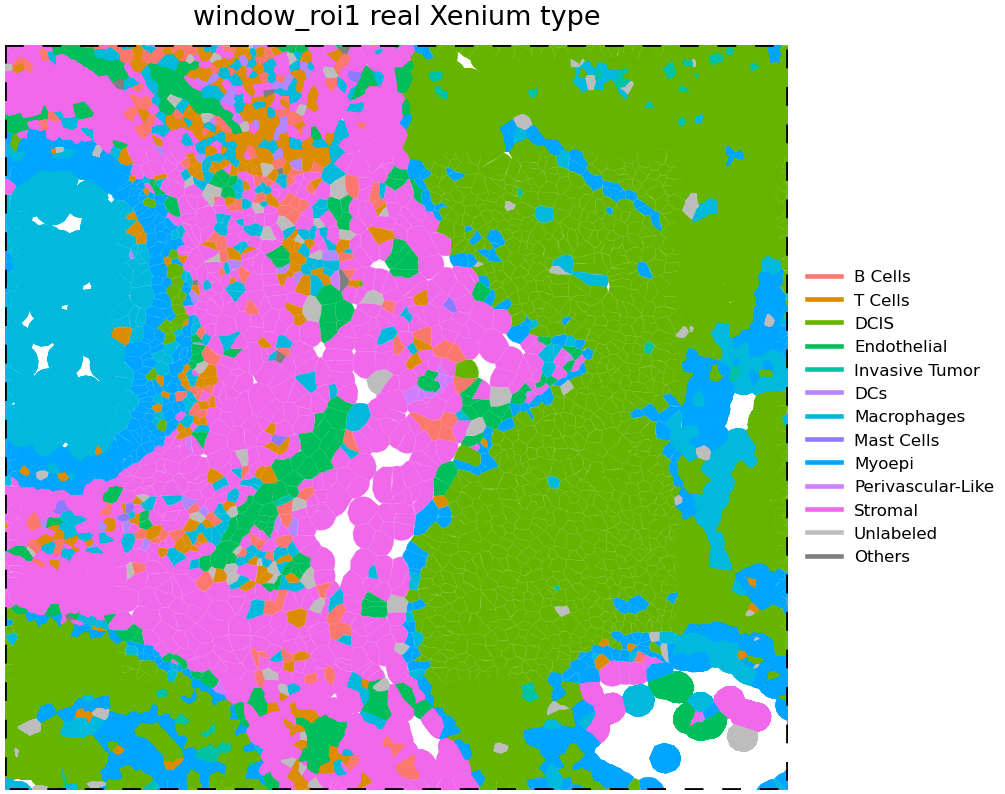
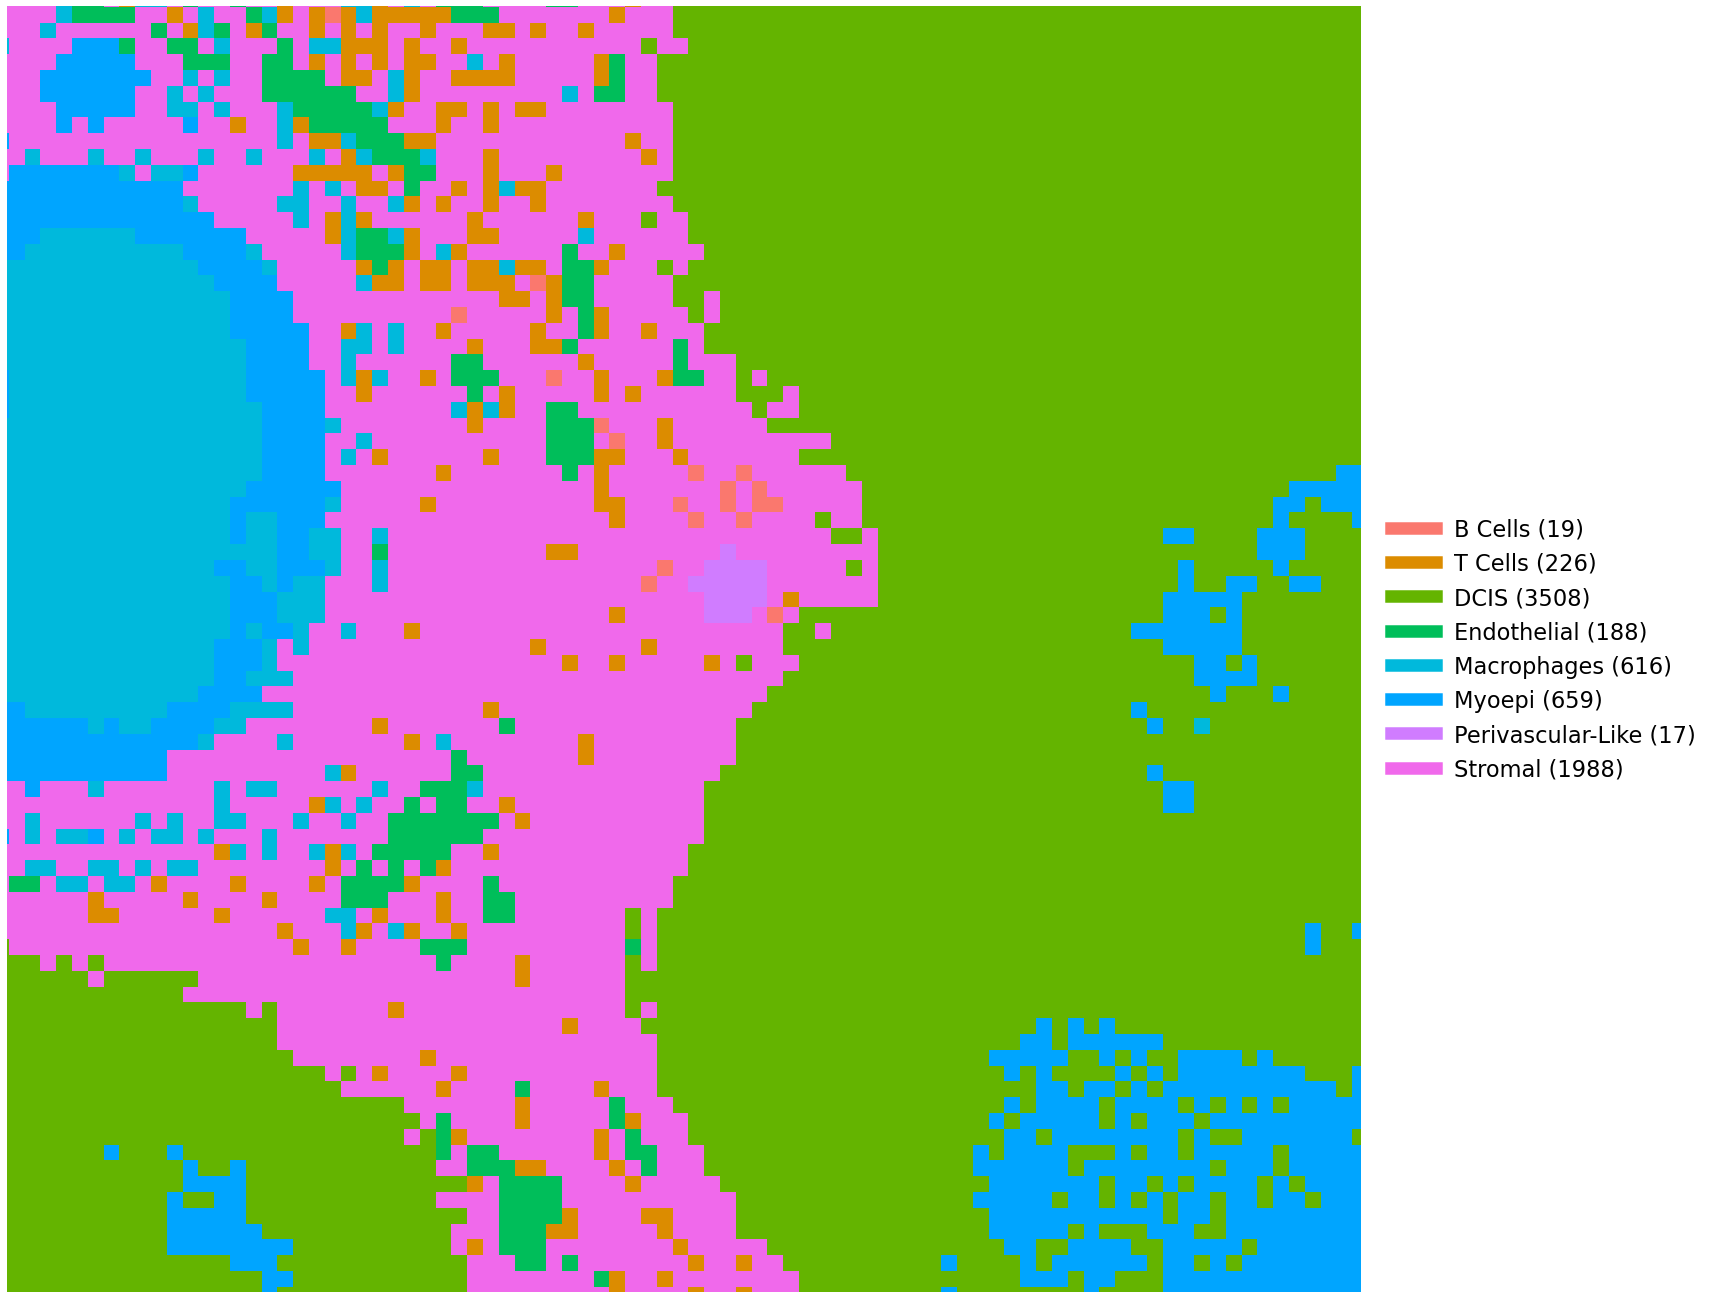

In [3]:
type_plot = spacerec.plottype(
    dataset=dataset,
    grid_type_csv=grid_type_csv,
    true_xen_type_csv=true_xen_type_csv,
    type_merge_json=type_merge_json,
    window=type_evaluation_window,
    window_label=type_window_label,
    output_dir=evaluation_dir,
)
display_image_pair(type_plot["true_type_png"], type_plot["grid_type_png"])


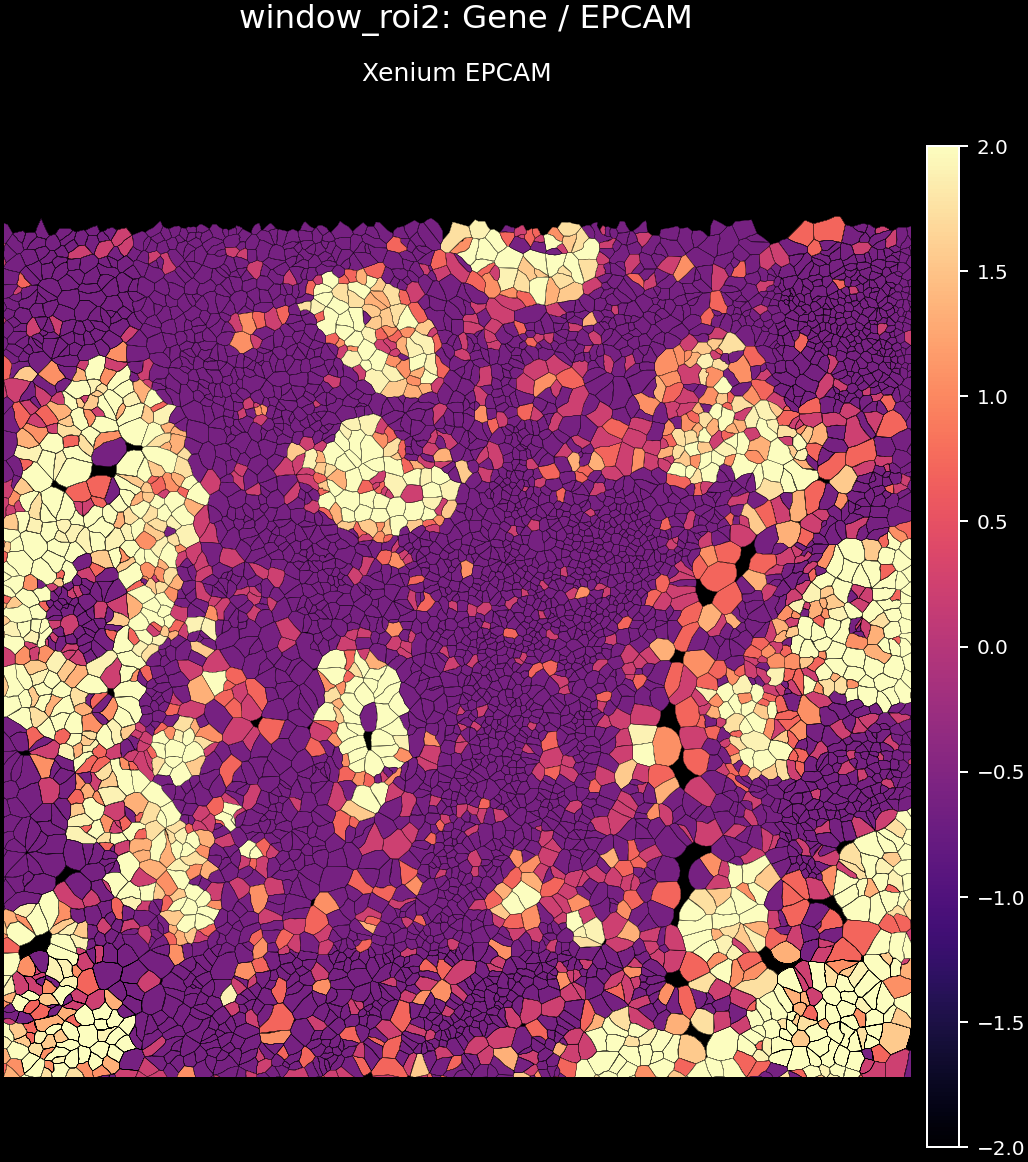
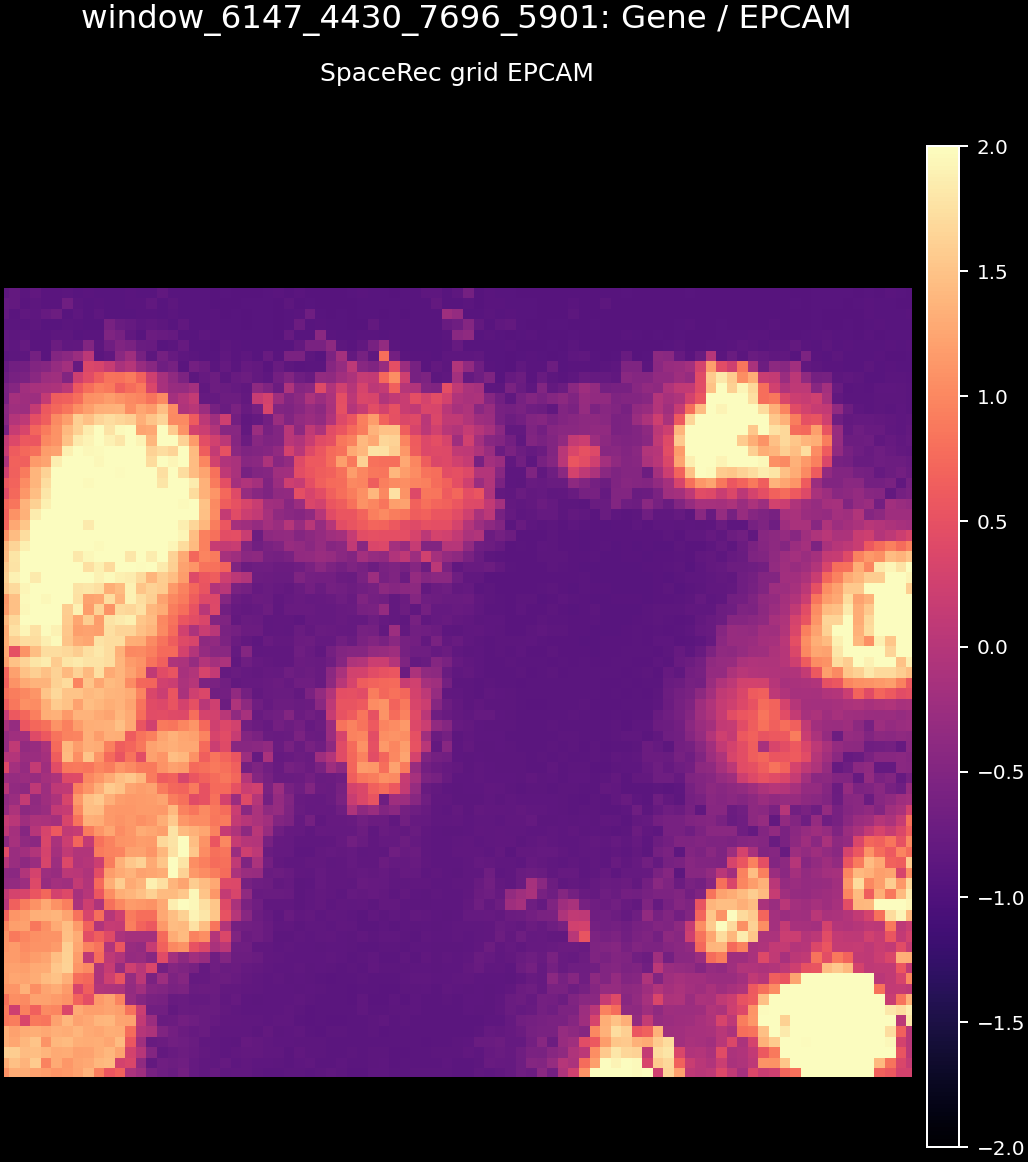

In [4]:
expr_plot = spacerec.plotexpr(
    dataset=dataset,
    grid_expr_h5ad=grid_expr_h5ad,
    true_xen_expr_h5=true_xen_expr_h5,
    true_xen_type_csv=true_xen_type_csv,
    polygon_window_label=expr_polygon_window_label,
    window=expr_evaluation_window,
    output_dir=evaluation_dir,
    gene=evaluation_gene,
)
display_image_pair(expr_plot["xen_expr_png"], expr_plot["grid_expr_png"])